# IC3392 OIII5006 high-S/N outlier inspection

Focused follow-up to the 2026-05-10 same-binning GAS comparison.

Goal: isolate `OIII5006` bins where the two same-binning runs disagree strongly in velocity or sigma, then check whether the suspicious bins look like ordinary noisy OIII behavior or whether one run is visibly worse.

Runs compared here:

- reference / x axis: `7.6.8 7000/53 same-bin`
- comparison / y axis: `7.6.8 9100/40`

This notebook uses only OIII products, ranks high-`Flux/Err` outliers, and then extracts the observed binned spectrum around OIII from the local IC3392 cube when available. The spectral overlay is a quick-look diagnostic: it subtracts a local linear continuum and overlays Gaussian profiles implied by each run's fitted `VEL` and `SIGMA`, with the amplitude refit locally for visual comparison.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from astropy.io import fits

pd.set_option('display.max_columns', 180)
pd.set_option('display.max_rows', 260)
pd.set_option('display.max_colwidth', 180)

plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 160,
    'axes.grid': False,
})

root = Path.cwd()
GALAXY = 'IC3392'
OIII_LINE = 'OIII5006'
OIII_LABEL = '[O III] 5006'
OIII_REST_A = 5006.843
REDSHIFT = 0.005566
C_KMS = 299792.458

RUNS = {
    'v768_7000_53_samebinning': {
        'label': 'v3tk_v7.6.8 7000/53 setup, same binning as 9100/40',
        'plot_label': '7.6.8 7000/53 same-bin',
        'gas_path': root / 'v3tk_v7.6.8_7000_samebinning' / GALAXY / f'{GALAXY}_gas_bin_maps.fits',
        'color': '#1f77b4',
    },
    'v768_9100_40': {
        'label': 'v3tk_v7.6.8 9100/40',
        'plot_label': '7.6.8 9100/40',
        'gas_path': root / 'v3tk_v7.6.8_VELSCALE40' / GALAXY / f'{GALAXY}_gas_bin_maps.fits',
        'color': '#d62728',
    },
}
BASELINE_RUN = 'v768_7000_53_samebinning'
COMPARE_RUN = 'v768_9100_40'
RUN_ORDER = [BASELINE_RUN, COMPARE_RUN]

CUBE_CANDIDATES = [
    root / '..' / 'v3tk_to_R' / 'IC3392_DATACUBE_FINAL_WCS_Pall_mad_red_v3tk.fits',
    root / '..' / 'data' / GALAXY / 'IC3392_DATACUBE_FINAL_WCS_Pall_mad_red_v3.fits',
]
CUBE_PATH = next((path for path in CUBE_CANDIDATES if path.exists()), None)

SNR_CUTS = [0, 3, 5, 10, 20, 50]
HIGH_SNR_CUT = 20
N_TOP_SIGMA = 6
N_TOP_VEL = 6
N_SPECTRA_TO_PLOT = 10

run_table = []
for run_key, run in RUNS.items():
    path = run['gas_path']
    run_table.append({
        'run_key': run_key,
        'label': run['label'],
        'gas_path': str(path.relative_to(root)),
        'exists': path.exists(),
        'size_MB': path.stat().st_size / 1024**2 if path.exists() else np.nan,
    })
run_table = pd.DataFrame(run_table)
display(run_table)
print('Cube path:', CUBE_PATH if CUBE_PATH is not None else 'No local cube found')
assert run_table['exists'].all(), 'Missing one or more GAS map files.'


,run_key,label,gas_path,exists,size_MB
0,v768_7000_53_samebinning,"v3tk_v7.6.8 7000/53 setup, same binning as 9100/40",v3tk_v7.6.8_7000_samebinning/IC3392/IC3392_gas_bin_maps.fits,True,152.251282
1,v768_9100_40,v3tk_v7.6.8 9100/40,v3tk_v7.6.8_VELSCALE40/IC3392/IC3392_gas_bin_maps.fits,True,223.983765


Cube path: /Users/Igniz/Desktop/ICRAR/further/../v3tk_to_R/IC3392_DATACUBE_FINAL_WCS_Pall_mad_red_v3tk.fits


## Load OIII Maps And Verify Binning

Only the OIII HDUs are loaded. The `BIN_ID` maps must be exactly identical for the outlier ranking to be interpreted as a same-binning comparison.


,run_key,n_extensions,missing_oiii_extensions,all_oiii_available
0,v768_7000_53_samebinning,105,,True
1,v768_9100_40,154,,True


,same_shape,exact_equal_including_nan,finite_pixels_in_both,n_finite_mismatches,n_unique_bins
0,True,True,94543,0,4032


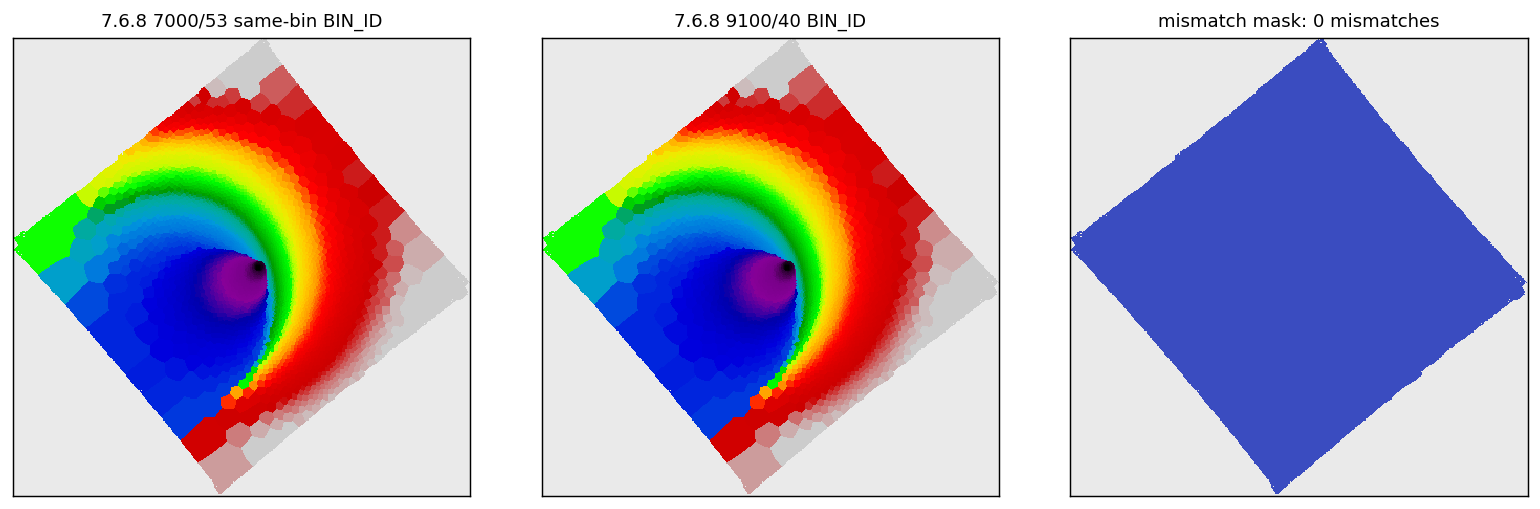

In [2]:
OIII_EXTENSIONS = [
    'BIN_ID',
    f'{OIII_LINE}_FLUX',
    f'{OIII_LINE}_FLUX_ERR',
    f'{OIII_LINE}_VEL',
    f'{OIII_LINE}_VEL_ERR',
    f'{OIII_LINE}_SIGMA',
    f'{OIII_LINE}_SIGMA_ERR',
    f'{OIII_LINE}_SIGMA_CORR',
]


def fits_extnames(path):
    with fits.open(path, memmap=False, ignore_missing_end=True) as hdul:
        return [hdu.name for hdu in hdul]


def read_map(path, extname):
    with fits.open(path, memmap=False, ignore_missing_end=True) as hdul:
        arr = np.array(hdul[extname].data, dtype=float)
    arr[~np.isfinite(arr)] = np.nan
    return arr


availability_rows = []
for run_key in RUN_ORDER:
    extnames = set(fits_extnames(RUNS[run_key]['gas_path']))
    missing = [ext for ext in OIII_EXTENSIONS if ext not in extnames]
    availability_rows.append({
        'run_key': run_key,
        'n_extensions': len(extnames),
        'missing_oiii_extensions': ', '.join(missing),
        'all_oiii_available': len(missing) == 0,
    })
availability = pd.DataFrame(availability_rows)
display(availability)
assert availability['all_oiii_available'].all(), 'Required OIII extensions are missing.'

maps = {
    extname: {run_key: read_map(RUNS[run_key]['gas_path'], extname) for run_key in RUN_ORDER}
    for extname in OIII_EXTENSIONS
}

baseline_bins = maps['BIN_ID'][BASELINE_RUN]
compare_bins = maps['BIN_ID'][COMPARE_RUN]
same_shape = baseline_bins.shape == compare_bins.shape
exact_equal = bool(same_shape and np.array_equal(baseline_bins, compare_bins, equal_nan=True))
finite_both = np.isfinite(baseline_bins) & np.isfinite(compare_bins)
n_mismatch = int(np.count_nonzero(finite_both & (baseline_bins != compare_bins))) if same_shape else np.nan
binning_check = pd.DataFrame([{
    'same_shape': same_shape,
    'exact_equal_including_nan': exact_equal,
    'finite_pixels_in_both': int(finite_both.sum()) if same_shape else np.nan,
    'n_finite_mismatches': n_mismatch,
    'n_unique_bins': int(np.unique(baseline_bins[np.isfinite(baseline_bins) & (baseline_bins >= 0)]).size),
}])
display(binning_check)
assert exact_equal, 'The two runs do not have identical BIN_ID maps.'

fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.8), constrained_layout=True)
cmap_bins = plt.get_cmap('nipy_spectral').copy()
cmap_bins.set_bad('0.92')
cmap_mismatch = plt.get_cmap('coolwarm').copy()
cmap_mismatch.set_bad('0.92')
for ax, arr, title in [
    (axes[0], baseline_bins, f'{RUNS[BASELINE_RUN]["plot_label"]} BIN_ID'),
    (axes[1], compare_bins, f'{RUNS[COMPARE_RUN]["plot_label"]} BIN_ID'),
]:
    ax.imshow(np.ma.masked_invalid(arr), origin='lower', cmap=cmap_bins, interpolation='nearest')
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
mismatch = np.full(baseline_bins.shape, np.nan, dtype=float)
mismatch[finite_both] = baseline_bins[finite_both] != compare_bins[finite_both]
axes[2].imshow(mismatch, origin='lower', cmap=cmap_mismatch, vmin=0, vmax=1, interpolation='nearest')
axes[2].set_title(f'mismatch mask: {n_mismatch} mismatches', fontsize=10)
axes[2].set_xticks([])
axes[2].set_yticks([])
plt.show()


## Build One-Row-Per-Bin OIII Table

The GAS maps are image-shaped, so this table collapses each `BIN_ID` to one median row. It keeps OIII flux/error, velocity, sigma, formal errors, residuals, ratios, and bin-center coordinates.


In [3]:
def line_fluxerr(run_key):
    flux = maps[f'{OIII_LINE}_FLUX'][run_key]
    err = maps[f'{OIII_LINE}_FLUX_ERR'][run_key]
    ratio = np.full(flux.shape, np.nan, dtype=float)
    valid = np.isfinite(flux) & np.isfinite(err) & (err > 0)
    ratio[valid] = flux[valid] / err[valid]
    return ratio


def robust_sigma(values):
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan
    return float(0.5 * (np.nanpercentile(values, 84) - np.nanpercentile(values, 16)))


fluxerr_maps = {run_key: line_fluxerr(run_key) for run_key in RUN_ORDER}
rows, cols = np.indices(baseline_bins.shape)
valid_bin_pixels = np.isfinite(baseline_bins) & (baseline_bins >= 0)

pixel_table = pd.DataFrame({
    'bin_id': baseline_bins[valid_bin_pixels].astype(int),
    'row': rows[valid_bin_pixels].astype(float),
    'col': cols[valid_bin_pixels].astype(float),
})
for run_key in RUN_ORDER:
    prefix = 'ref' if run_key == BASELINE_RUN else 'cmp'
    pixel_table[f'{prefix}_flux'] = maps[f'{OIII_LINE}_FLUX'][run_key][valid_bin_pixels]
    pixel_table[f'{prefix}_fluxerr'] = fluxerr_maps[run_key][valid_bin_pixels]
    pixel_table[f'{prefix}_vel'] = maps[f'{OIII_LINE}_VEL'][run_key][valid_bin_pixels]
    pixel_table[f'{prefix}_vel_err'] = maps[f'{OIII_LINE}_VEL_ERR'][run_key][valid_bin_pixels]
    pixel_table[f'{prefix}_sigma'] = maps[f'{OIII_LINE}_SIGMA'][run_key][valid_bin_pixels]
    pixel_table[f'{prefix}_sigma_err'] = maps[f'{OIII_LINE}_SIGMA_ERR'][run_key][valid_bin_pixels]
    pixel_table[f'{prefix}_sigma_corr'] = maps[f'{OIII_LINE}_SIGMA_CORR'][run_key][valid_bin_pixels]

agg = {col: 'median' for col in pixel_table.columns if col != 'bin_id'}
agg['row'] = 'median'
agg['col'] = 'median'
bin_table = pixel_table.groupby('bin_id', as_index=False).agg(agg)
bin_table['n_spaxels'] = pixel_table.groupby('bin_id').size().to_numpy()

bin_table['both_fluxerr_min'] = bin_table[['ref_fluxerr', 'cmp_fluxerr']].min(axis=1)
bin_table['delta_vel'] = bin_table['cmp_vel'] - bin_table['ref_vel']
bin_table['abs_delta_vel'] = np.abs(bin_table['delta_vel'])
bin_table['delta_sigma'] = bin_table['cmp_sigma'] - bin_table['ref_sigma']
bin_table['abs_delta_sigma'] = np.abs(bin_table['delta_sigma'])
bin_table['sigma_ratio'] = bin_table['cmp_sigma'] / bin_table['ref_sigma']
bin_table.loc[~np.isfinite(bin_table['sigma_ratio']) | (bin_table['sigma_ratio'] <= 0), 'sigma_ratio'] = np.nan
bin_table['log10_sigma_ratio'] = np.log10(bin_table['sigma_ratio'])
bin_table['abs_log10_sigma_ratio'] = np.abs(bin_table['log10_sigma_ratio'])

vel_err_quad = np.sqrt(bin_table['ref_vel_err']**2 + bin_table['cmp_vel_err']**2)
sigma_err_quad = np.sqrt(bin_table['ref_sigma_err']**2 + bin_table['cmp_sigma_err']**2)
bin_table['delta_vel_over_formal_err'] = bin_table['delta_vel'] / vel_err_quad.replace(0, np.nan)
bin_table['delta_sigma_over_formal_err'] = bin_table['delta_sigma'] / sigma_err_quad.replace(0, np.nan)
bin_table['abs_delta_vel_over_formal_err'] = np.abs(bin_table['delta_vel_over_formal_err'])
bin_table['abs_delta_sigma_over_formal_err'] = np.abs(bin_table['delta_sigma_over_formal_err'])

summary_cols = [
    'bin_id', 'row', 'col', 'n_spaxels', 'ref_fluxerr', 'cmp_fluxerr', 'both_fluxerr_min',
    'ref_vel', 'cmp_vel', 'delta_vel', 'abs_delta_vel', 'ref_sigma', 'cmp_sigma',
    'delta_sigma', 'abs_delta_sigma', 'sigma_ratio', 'log10_sigma_ratio',
    'ref_vel_err', 'cmp_vel_err', 'ref_sigma_err', 'cmp_sigma_err',
]
display(bin_table[summary_cols].head())
print(f'One row per OIII bin: {len(bin_table):,}')


,bin_id,row,col,n_spaxels,ref_fluxerr,cmp_fluxerr,both_fluxerr_min,ref_vel,cmp_vel,delta_vel,abs_delta_vel,ref_sigma,cmp_sigma,delta_sigma,abs_delta_sigma,sigma_ratio,log10_sigma_ratio,ref_vel_err,cmp_vel_err,ref_sigma_err,cmp_sigma_err
0,0,219.0,233.0,1,10.379920,10.160082,10.160082,24.346302,30.560027,6.213725,6.213725,82.276645,73.160931,-9.115714,9.115714,0.889207,-0.050997,11.200067,9.694496,17.990619,19.349780
1,1,219.0,234.0,1,8.815816,8.300797,8.300797,1.666905,3.594018,1.927113,1.927113,93.455133,87.114472,-6.340662,6.340662,0.932153,-0.030513,15.391011,14.119642,21.088208,14.603677
2,2,218.0,234.0,1,9.841161,6.612452,6.612452,14.226059,-21.954909,-36.180967,36.180967,64.616388,173.329495,108.713107,108.713107,2.682439,0.428530,9.384720,20.451046,66.950492,20.660423
3,3,218.0,233.0,1,11.095179,10.129309,10.129309,13.638244,-4.725858,-18.364102,18.364102,97.317618,167.180262,69.862644,69.862644,1.717883,0.234994,12.432965,18.144719,16.768479,18.376950
4,4,218.0,235.0,1,7.866447,6.193759,6.193759,63.026453,15.333820,-47.692632,47.692632,101.964187,179.755880,77.791694,77.791694,1.762932,0.246235,18.397380,24.858951,24.542005,25.853937


One row per OIII bin: 4,032


## OIII S/N Population And Outlier Ranking

The high-S/N working sample defaults to bins with `Flux/Err > 20` in both runs. The selected-bin list is the union of the largest `abs(log10 sigma ratio)` bins and the largest `abs(delta velocity)` bins in that high-S/N sample.


In [4]:
population_rows = []
for cut in SNR_CUTS:
    subset = bin_table[bin_table['both_fluxerr_min'] > cut]
    population_rows.append({
        'fluxerr_cut_in_both_runs': f'>{cut:g}',
        'n_bins': int(len(subset)),
        'fraction_of_bins': float(len(subset) / len(bin_table)),
        'median_ref_fluxerr': float(np.nanmedian(subset['ref_fluxerr'])) if len(subset) else np.nan,
        'median_cmp_fluxerr': float(np.nanmedian(subset['cmp_fluxerr'])) if len(subset) else np.nan,
        'median_delta_vel': float(np.nanmedian(subset['delta_vel'])) if len(subset) else np.nan,
        'robust_sigma_delta_vel': robust_sigma(subset['delta_vel']) if len(subset) else np.nan,
        'median_delta_sigma': float(np.nanmedian(subset['delta_sigma'])) if len(subset) else np.nan,
        'robust_sigma_delta_sigma': robust_sigma(subset['delta_sigma']) if len(subset) else np.nan,
        'median_sigma_ratio': float(np.nanmedian(subset['sigma_ratio'])) if len(subset) else np.nan,
        'robust_sigma_log10_ratio': robust_sigma(subset['log10_sigma_ratio']) if len(subset) else np.nan,
    })
population_summary = pd.DataFrame(population_rows)
display(population_summary)

high_snr = bin_table[
    (bin_table['both_fluxerr_min'] > HIGH_SNR_CUT)
    & np.isfinite(bin_table['delta_vel'])
    & np.isfinite(bin_table['log10_sigma_ratio'])
].copy()

sigma_outliers = high_snr.sort_values('abs_log10_sigma_ratio', ascending=False).head(N_TOP_SIGMA).copy()
sigma_outliers['selection_reason'] = 'large sigma ratio'
vel_outliers = high_snr.sort_values('abs_delta_vel', ascending=False).head(N_TOP_VEL).copy()
vel_outliers['selection_reason'] = 'large velocity difference'
selected_bins = pd.concat([sigma_outliers, vel_outliers], ignore_index=True)
selected_bins = selected_bins.sort_values(['bin_id', 'selection_reason']).drop_duplicates('bin_id', keep='first')
selected_bins = selected_bins.sort_values(['abs_log10_sigma_ratio', 'abs_delta_vel'], ascending=False).reset_index(drop=True)

selected_cols = [
    'selection_reason', 'bin_id', 'row', 'col', 'n_spaxels', 'both_fluxerr_min',
    'ref_fluxerr', 'cmp_fluxerr', 'delta_vel', 'abs_delta_vel',
    'delta_sigma', 'abs_delta_sigma', 'sigma_ratio', 'log10_sigma_ratio',
    'ref_vel', 'cmp_vel', 'ref_sigma', 'cmp_sigma',
    'abs_delta_vel_over_formal_err', 'abs_delta_sigma_over_formal_err',
]
display(selected_bins[selected_cols])

print(f'High-S/N OIII bins with Flux/Err > {HIGH_SNR_CUT:g} in both runs: {len(high_snr):,}')
print(f'Selected suspicious bins for visual inspection: {len(selected_bins):,}')


,fluxerr_cut_in_both_runs,n_bins,fraction_of_bins,median_ref_fluxerr,median_cmp_fluxerr,median_delta_vel,robust_sigma_delta_vel,median_delta_sigma,robust_sigma_delta_sigma,median_sigma_ratio,robust_sigma_log10_ratio
0,>0,3996,0.991071,9.055547,8.643954,-1.084776,34.036912,1.825377,27.718189,1.021013,0.104645
1,>3,3809,0.944692,9.247487,8.860686,-0.964279,30.893178,1.331013,27.276026,1.017397,0.102015
2,>5,3378,0.837798,9.693619,9.332435,-0.939495,26.163086,1.514974,26.080970,1.018881,0.095922
3,>10,1361,0.337550,12.402665,12.258852,-1.136025,15.589451,2.804637,19.543203,1.034372,0.071268
4,>20,59,0.014633,24.016560,24.554049,-0.724511,3.290024,6.508748,7.818408,1.062135,0.034192
5,>50,1,0.000248,52.031861,52.645872,-1.312984,0.000000,2.036835,0.000000,1.023103,0.000000


,selection_reason,bin_id,row,col,n_spaxels,both_fluxerr_min,ref_fluxerr,cmp_fluxerr,delta_vel,abs_delta_vel,delta_sigma,abs_delta_sigma,sigma_ratio,log10_sigma_ratio,ref_vel,cmp_vel,ref_sigma,cmp_sigma,abs_delta_vel_over_formal_err,abs_delta_sigma_over_formal_err
0,large sigma ratio,908,87.0,187.0,451,22.660587,22.660587,23.446891,1.538136,1.538136,52.786806,52.786806,1.445554,0.160034,4.913349,6.451486,118.474543,171.261349,0.135463,4.385789
1,large sigma ratio,3277,200.0,292.0,8,20.713541,20.713541,20.746265,-4.006540,4.006540,42.071889,42.071889,1.409973,0.149211,-21.449641,-25.456181,102.621033,144.692923,0.381275,3.371829
2,large sigma ratio,2369,304.0,162.0,16,20.822391,22.320831,20.822391,23.540324,23.540324,-23.438078,23.438078,0.742164,-0.129500,100.166363,123.706687,90.903007,67.464929,3.886073,2.566210
3,large sigma ratio,347,195.0,213.0,11,26.311498,26.576036,26.311498,-1.733392,1.733392,-27.775585,27.775585,0.746331,-0.127069,29.486577,27.753184,109.495352,81.719768,0.283732,3.644813
4,large sigma ratio,2358,297.5,192.0,10,20.131734,21.097449,20.131734,16.598094,16.598094,-24.129585,24.129585,0.750138,-0.124859,104.934936,121.533030,96.571649,72.442063,2.355648,2.416077
5,large sigma ratio,2310,229.5,256.5,4,20.687368,20.820768,20.687368,-6.016022,6.016022,31.301420,31.301420,1.325290,0.122311,-2.560149,-8.576171,96.226285,127.527705,0.631349,2.670008
6,large velocity difference,2254,296.0,190.0,9,20.772796,21.201866,20.772796,11.241007,11.241007,-19.596365,19.596365,0.804374,-0.094542,107.904101,119.145108,100.172819,80.576453,1.497576,1.984625
7,large velocity difference,381,193.0,211.0,11,34.735023,35.873955,34.735023,-16.968275,16.968275,-15.995271,15.995271,0.866544,-0.062209,59.726059,42.757784,119.854143,103.858872,3.087433,2.453576
8,large velocity difference,2349,298.5,188.0,10,21.881667,22.075691,21.881667,21.302444,21.302444,-9.288345,9.288345,0.889381,-0.050912,104.666720,125.969164,83.967301,74.678956,3.560719,1.000066
9,large velocity difference,3354,164.0,284.0,9,21.572330,22.233704,21.572330,-14.579143,14.579143,1.912483,1.912483,1.020818,0.008948,-50.901795,-65.480938,91.868532,93.781015,1.877958,0.171852


High-S/N OIII bins with Flux/Err > 20 in both runs: 59
Selected suspicious bins for visual inspection: 10


## OIII Maps With Selected Bins

These maps show where the selected suspicious bins sit relative to OIII signal-to-noise, velocity residuals, and sigma-ratio structure.


### How The Map Diagnostic Figure Is Built

The next cell plots image-space OIII diagnostics from the two already-loaded GAS map files. The background maps use all finite OIII map pixels, not only the high-S/N subset, so you can see where the suspicious bins sit in the full galaxy context.

The plotted quantities are:

- `Flux/Err` in the `7000/53 same-bin` run.
- `Flux/Err` in the `9100/40` run.
- the minimum of the two `Flux/Err` maps, which shows where both runs have usable OIII signal.
- `delta VEL = VEL_9100/40 - VEL_7000/53_samebin`.
- `delta SIGMA = SIGMA_9100/40 - SIGMA_7000/53_samebin`.
- `log10(SIGMA_9100/40 / SIGMA_7000/53_samebin)`.

The black circles are the `selected_bins` from the previous ranking cell. Their positions are the median row/column of all spaxels in that `BIN_ID`, and the text labels are the bin IDs. Color limits are robust: percentile limits for Flux/Err maps, and symmetric percentile limits for residual/ratio maps, so a few extreme pixels do not flatten the useful contrast.


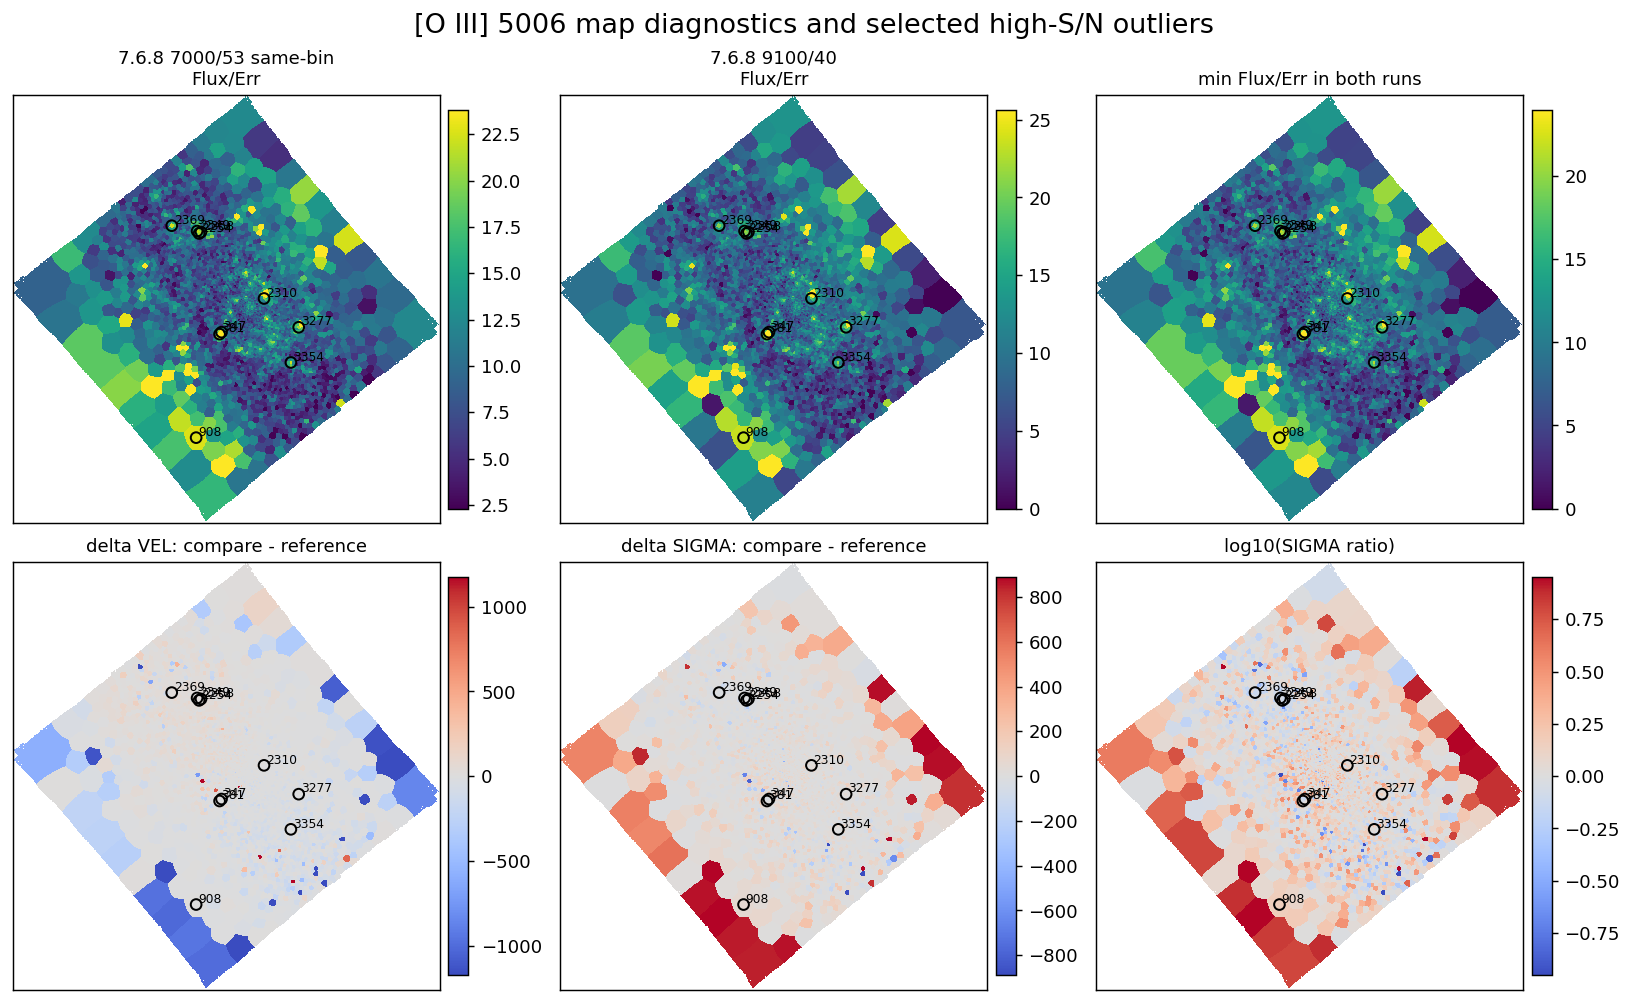

In [5]:
def robust_limits(values, p=(2, 98), pad_fraction=0.06, fallback=(-1, 1)):
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return fallback
    lo, hi = np.nanpercentile(values, p)
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        center = np.nanmedian(values)
        spread = np.nanstd(values)
        spread = spread if np.isfinite(spread) and spread > 0 else 1.0
        lo, hi = center - spread, center + spread
    pad = pad_fraction * (hi - lo)
    return float(lo - pad), float(hi + pad)


def symmetric_limit(values, percentile=98, fallback=1.0):
    values = np.abs(np.asarray(values)[np.isfinite(values)])
    if values.size == 0:
        return fallback
    limit = np.nanpercentile(values, percentile)
    return float(limit if np.isfinite(limit) and limit > 0 else fallback)


delta_vel_map = maps[f'{OIII_LINE}_VEL'][COMPARE_RUN] - maps[f'{OIII_LINE}_VEL'][BASELINE_RUN]
delta_sigma_map = maps[f'{OIII_LINE}_SIGMA'][COMPARE_RUN] - maps[f'{OIII_LINE}_SIGMA'][BASELINE_RUN]
sigma_ratio_map = maps[f'{OIII_LINE}_SIGMA'][COMPARE_RUN] / maps[f'{OIII_LINE}_SIGMA'][BASELINE_RUN]
sigma_ratio_map[~np.isfinite(sigma_ratio_map) | (sigma_ratio_map <= 0)] = np.nan
log_sigma_ratio_map = np.log10(sigma_ratio_map)

fig, axes = plt.subplots(2, 3, figsize=(12.5, 7.6), constrained_layout=True)
fig.suptitle(f'{OIII_LABEL} map diagnostics and selected high-S/N outliers', fontsize=15)

panels = [
    (axes[0, 0], fluxerr_maps[BASELINE_RUN], f'{RUNS[BASELINE_RUN]["plot_label"]}\nFlux/Err', 'viridis', None),
    (axes[0, 1], fluxerr_maps[COMPARE_RUN], f'{RUNS[COMPARE_RUN]["plot_label"]}\nFlux/Err', 'viridis', None),
    (axes[0, 2], np.minimum(fluxerr_maps[BASELINE_RUN], fluxerr_maps[COMPARE_RUN]), 'min Flux/Err in both runs', 'viridis', None),
    (axes[1, 0], delta_vel_map, 'delta VEL: compare - reference', 'coolwarm', symmetric_limit(delta_vel_map, 98, 25)),
    (axes[1, 1], delta_sigma_map, 'delta SIGMA: compare - reference', 'coolwarm', symmetric_limit(delta_sigma_map, 98, 25)),
    (axes[1, 2], log_sigma_ratio_map, 'log10(SIGMA ratio)', 'coolwarm', symmetric_limit(log_sigma_ratio_map, 98, 0.3)),
]

for ax, arr, title, cmap, lim in panels:
    plot_arr = np.ma.masked_invalid(arr)
    if lim is None:
        vmin, vmax = robust_limits(arr, p=(2, 98), fallback=(0, 20))
        im = ax.imshow(plot_arr, origin='lower', cmap=cmap, vmin=max(vmin, 0), vmax=vmax, interpolation='nearest')
    else:
        im = ax.imshow(plot_arr, origin='lower', cmap=cmap, vmin=-lim, vmax=lim, interpolation='nearest')
    ax.scatter(selected_bins['col'], selected_bins['row'], s=35, facecolors='none', edgecolors='black', linewidths=1.1)
    for _, row in selected_bins.iterrows():
        ax.text(row['col'] + 2, row['row'] + 2, str(int(row['bin_id'])), fontsize=6.8, color='black')
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

plt.show()


## OIII Pairwise And Ratio Views

Selected bins are highlighted on the same OIII-only pairwise views used for ranking.


### How The Pairwise/Ratio Plot Data Is Selected

The next cell switches from image pixels to the one-row-per-bin table. The gray point cloud is `high_snr`, defined in the ranking cell as bins with:

`min(Flux/Err_7000/53_samebin, Flux/Err_9100/40) > HIGH_SNR_CUT`

where `HIGH_SNR_CUT = 20` by default. This keeps the pairwise views focused on bins where OIII is at least plausibly measured in both runs.

The highlighted/labeled points are the same `selected_bins`: the union of the largest sigma-ratio outliers and the largest velocity-difference outliers. The four panels show velocity agreement, velocity residuals, sigma agreement in log-log space, and the sigma ratio as `log10(SIGMA_9100/40 / SIGMA_7000/53_samebin)`.


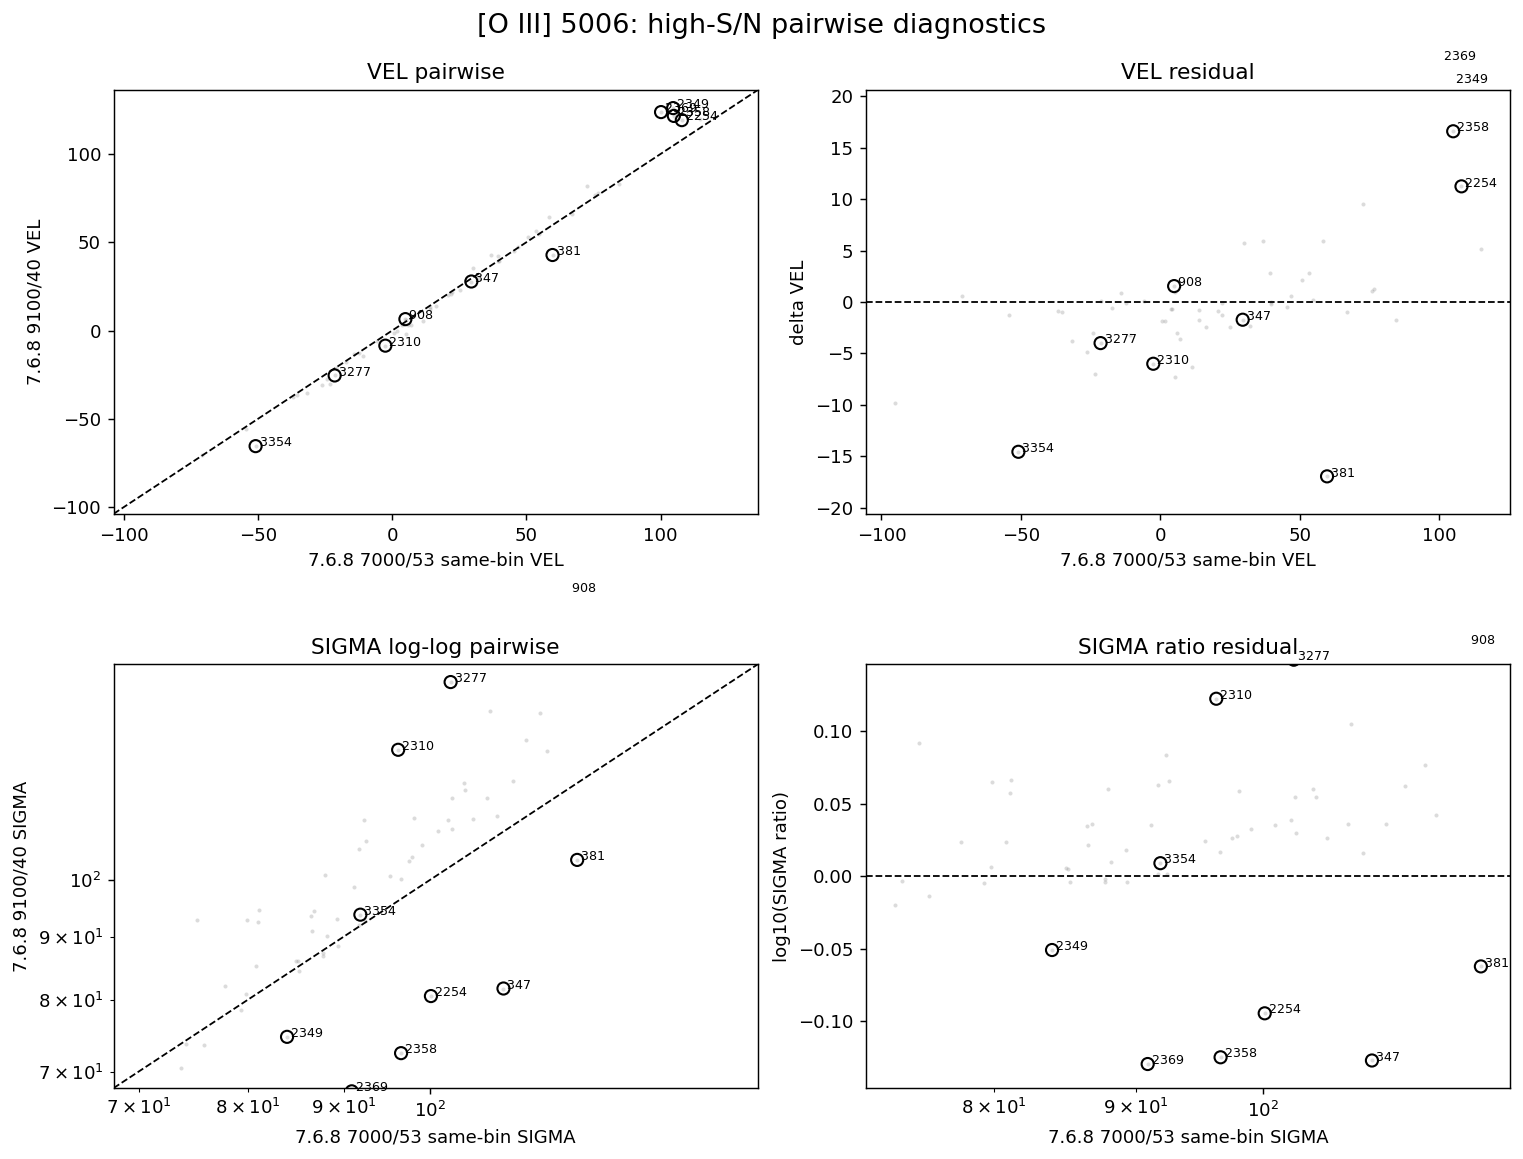

In [6]:
def scatter_selected(ax, x_col, y_col, color='black'):
    ax.scatter(selected_bins[x_col], selected_bins[y_col], s=45, facecolors='none', edgecolors=color, linewidths=1.15, zorder=5)
    for _, row in selected_bins.iterrows():
        ax.text(row[x_col], row[y_col], f' {int(row["bin_id"])}', fontsize=7, color=color, zorder=6)


fig, axes = plt.subplots(2, 2, figsize=(11.6, 8.8), constrained_layout=True)
fig.suptitle(f'{OIII_LABEL}: high-S/N pairwise diagnostics', fontsize=15)

plot_sample = high_snr.copy()
if len(plot_sample) > 25000:
    plot_sample = plot_sample.sample(25000, random_state=12)

ax = axes[0, 0]
lo, hi = robust_limits(high_snr[['ref_vel', 'cmp_vel']].to_numpy().ravel(), p=(1, 99), fallback=(-150, 150))
ax.scatter(plot_sample['ref_vel'], plot_sample['cmp_vel'], s=5, alpha=0.25, linewidths=0, color='0.45')
ax.plot([lo, hi], [lo, hi], color='black', linestyle='--', linewidth=1)
scatter_selected(ax, 'ref_vel', 'cmp_vel')
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel(f'{RUNS[BASELINE_RUN]["plot_label"]} VEL')
ax.set_ylabel(f'{RUNS[COMPARE_RUN]["plot_label"]} VEL')
ax.set_title('VEL pairwise')

ax = axes[0, 1]
vel_lim = symmetric_limit(high_snr['delta_vel'], 98, 25)
ax.scatter(plot_sample['ref_vel'], plot_sample['delta_vel'], s=5, alpha=0.25, linewidths=0, color='0.45')
ax.scatter(selected_bins['ref_vel'], selected_bins['delta_vel'], s=45, facecolors='none', edgecolors='black', linewidths=1.15)
for _, row in selected_bins.iterrows():
    ax.text(row['ref_vel'], row['delta_vel'], f' {int(row["bin_id"])}', fontsize=7)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_ylim(-vel_lim, vel_lim)
ax.set_xlabel(f'{RUNS[BASELINE_RUN]["plot_label"]} VEL')
ax.set_ylabel('delta VEL')
ax.set_title('VEL residual')

ax = axes[1, 0]
sigma_values = high_snr[['ref_sigma', 'cmp_sigma']].to_numpy().ravel()
sigma_values = sigma_values[np.isfinite(sigma_values) & (sigma_values > 0)]
slo_log, shi_log = robust_limits(np.log10(sigma_values), p=(1, 99), fallback=(np.log10(30), np.log10(400)))
slo, shi = 10**slo_log, 10**shi_log
ax.scatter(plot_sample['ref_sigma'], plot_sample['cmp_sigma'], s=5, alpha=0.25, linewidths=0, color='0.45')
ax.plot([slo, shi], [slo, shi], color='black', linestyle='--', linewidth=1)
scatter_selected(ax, 'ref_sigma', 'cmp_sigma')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(slo, shi)
ax.set_ylim(slo, shi)
ax.set_xlabel(f'{RUNS[BASELINE_RUN]["plot_label"]} SIGMA')
ax.set_ylabel(f'{RUNS[COMPARE_RUN]["plot_label"]} SIGMA')
ax.set_title('SIGMA log-log pairwise')

ax = axes[1, 1]
log_lim = symmetric_limit(high_snr['log10_sigma_ratio'], 98, 0.3)
ax.scatter(plot_sample['ref_sigma'], plot_sample['log10_sigma_ratio'], s=5, alpha=0.25, linewidths=0, color='0.45')
ax.scatter(selected_bins['ref_sigma'], selected_bins['log10_sigma_ratio'], s=45, facecolors='none', edgecolors='black', linewidths=1.15)
for _, row in selected_bins.iterrows():
    ax.text(row['ref_sigma'], row['log10_sigma_ratio'], f' {int(row["bin_id"])}', fontsize=7)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xscale('log')
ax.set_ylim(-log_lim, log_lim)
ax.set_xlabel(f'{RUNS[BASELINE_RUN]["plot_label"]} SIGMA')
ax.set_ylabel('log10(SIGMA ratio)')
ax.set_title('SIGMA ratio residual')

plt.show()


## Quick-Look Spectral Inspection Around OIII

This section extracts observed spectra from the local IC3392 cube for the selected bins. It uses the shared `BIN_ID` map, locally subtracts a linear continuum, then overlays two Gaussian profiles with centers/sigmas implied by the GAS maps. The amplitude is refit against the locally continuum-subtracted spectrum, so this is a shape/center sanity check rather than a reproduction of the full pPXF fit.


In [7]:
def wavelength_from_header(header, n_wave):
    crpix = header.get('CRPIX3', 1.0)
    crval = header.get('CRVAL3')
    cdelt = header.get('CDELT3', header.get('CD3_3'))
    if crval is None or cdelt is None:
        raise ValueError('Cannot construct wavelength vector from cube header.')
    return crval + (np.arange(n_wave) + 1 - crpix) * cdelt


def gaussian_unit(wave, center, sigma_a):
    if not np.isfinite(center) or not np.isfinite(sigma_a) or sigma_a <= 0:
        return np.full(wave.shape, np.nan)
    return np.exp(-0.5 * ((wave - center) / sigma_a) ** 2)


def fitted_gaussian_for_run(wave, spectrum_contsub, row, run_key, line_window_mask):
    prefix = 'ref' if run_key == BASELINE_RUN else 'cmp'
    vel = row[f'{prefix}_vel']
    sigma_kms = row[f'{prefix}_sigma']
    center = OIII_REST_A * (1.0 + REDSHIFT) * (1.0 + vel / C_KMS)
    sigma_a = center * sigma_kms / C_KMS
    profile = gaussian_unit(wave, center, sigma_a)
    fit_mask = line_window_mask & np.isfinite(profile) & np.isfinite(spectrum_contsub)
    if fit_mask.sum() < 3:
        amp = np.nan
        model = np.full(wave.shape, np.nan)
        rms = np.nan
    else:
        denom = np.nansum(profile[fit_mask] ** 2)
        amp = np.nansum(spectrum_contsub[fit_mask] * profile[fit_mask]) / denom if denom > 0 else np.nan
        model = amp * profile
        rms = np.sqrt(np.nanmean((spectrum_contsub[fit_mask] - model[fit_mask]) ** 2))
    return {
        'center': center,
        'sigma_a': sigma_a,
        'amp': amp,
        'model': model,
        'rms': rms,
        'vel': vel,
        'sigma_kms': sigma_kms,
    }


def extract_selected_bin_spectra(selected, wave_half_width=35.0, line_half_width=9.0, continuum_inner=14.0):
    if CUBE_PATH is None:
        print('No local cube found; skipping spectral extraction.')
        return []

    systemic_center = OIII_REST_A * (1.0 + REDSHIFT)
    with fits.open(CUBE_PATH, memmap=True) as hdul:
        cube = hdul['DATA'].data
        var = hdul['STAT'].data if 'STAT' in hdul else None
        wave = wavelength_from_header(hdul['DATA'].header, cube.shape[0])
        wave_mask = (wave >= systemic_center - wave_half_width) & (wave <= systemic_center + wave_half_width)
        wave_cut = wave[wave_mask]
        cube_cut = np.array(cube[wave_mask, :, :], dtype=float)
        var_cut = np.array(var[wave_mask, :, :], dtype=float) if var is not None else None

    line_window = np.abs(wave_cut - systemic_center) <= line_half_width
    continuum_window = (np.abs(wave_cut - systemic_center) >= continuum_inner) & np.isfinite(wave_cut)
    spectra = []

    for _, row in selected.iterrows():
        bin_id = int(row['bin_id'])
        bin_mask = baseline_bins == bin_id
        if not np.any(bin_mask):
            continue
        spectrum = np.nansum(cube_cut[:, bin_mask], axis=1)
        if var_cut is not None:
            variance = np.nansum(var_cut[:, bin_mask], axis=1)
            noise = np.sqrt(np.clip(variance, 0, np.inf))
        else:
            noise = np.full_like(spectrum, np.nan)

        continuum_fit_mask = continuum_window & np.isfinite(spectrum)
        if continuum_fit_mask.sum() >= 4:
            coeff = np.polyfit(wave_cut[continuum_fit_mask], spectrum[continuum_fit_mask], deg=1)
            continuum = np.polyval(coeff, wave_cut)
        else:
            continuum = np.full_like(spectrum, np.nanmedian(spectrum))
        contsub = spectrum - continuum

        ref_fit = fitted_gaussian_for_run(wave_cut, contsub, row, BASELINE_RUN, line_window)
        cmp_fit = fitted_gaussian_for_run(wave_cut, contsub, row, COMPARE_RUN, line_window)
        spectra.append({
            'bin_id': bin_id,
            'row': row,
            'wave': wave_cut,
            'spectrum': spectrum,
            'noise': noise,
            'continuum': continuum,
            'contsub': contsub,
            'line_window': line_window,
            'ref_fit': ref_fit,
            'cmp_fit': cmp_fit,
        })
    return spectra


spectra_to_plot = selected_bins.head(N_SPECTRA_TO_PLOT).copy()
selected_spectra = extract_selected_bin_spectra(spectra_to_plot)
print(f'Extracted spectra for {len(selected_spectra)} selected bins.')


Extracted spectra for 10 selected bins.


### How The Spectral Quick-Look Panels Are Constructed

The previous cell creates `selected_spectra` from the local MUSE cube, not from a pre-existing continuum-subtracted cube product. The steps are:

1. Choose the first `N_SPECTRA_TO_PLOT` rows of `selected_bins`. This is now set to `10`, matching the 10 selected suspicious bins. Lower `N_SPECTRA_TO_PLOT` in the setup cell if you want a smaller figure.
2. Open the local cube from `CUBE_PATH`, using the `DATA` HDU for flux and the `STAT` HDU for variance.
3. Build the wavelength vector from the cube header using `CRVAL3`, `CRPIX3`, and `CD3_3`/`CDELT3`.
4. Cut a narrow wavelength slab around systemic OIII: `OIII_REST_A * (1 + REDSHIFT)` plus/minus `35 Angstrom`.
5. For each selected `BIN_ID`, sum all cube spaxels belonging to that bin to make an observed binned spectrum.
6. Fit a local linear continuum using side-band pixels outside the central OIII region, then subtract that continuum. So “continuum-subtracted” here means a local quick-look subtraction made in this notebook, not the full pPXF stellar-continuum solution.
7. Sum the `STAT` variance over the same bin spaxels and take the square root; this is the gray `1 sigma noise` band.
8. Construct one Gaussian model per run using that run's map-level OIII `VEL` and `SIGMA` for the selected bin. The Gaussian center is `lambda_rest * (1 + z) * (1 + VEL/c)`, and the width is `sigma_lambda = center * SIGMA/c`.
9. Refit only the Gaussian amplitude against the local continuum-subtracted cube spectrum inside the central line window. This makes the overlay a center/width sanity check, not a reproduction of the full pPXF model or flux solution.

The orange shaded region is the central OIII line window, plus/minus `9 Angstrom` around systemic OIII. That window is used for the quick amplitude fit and the RMS number printed in each panel.


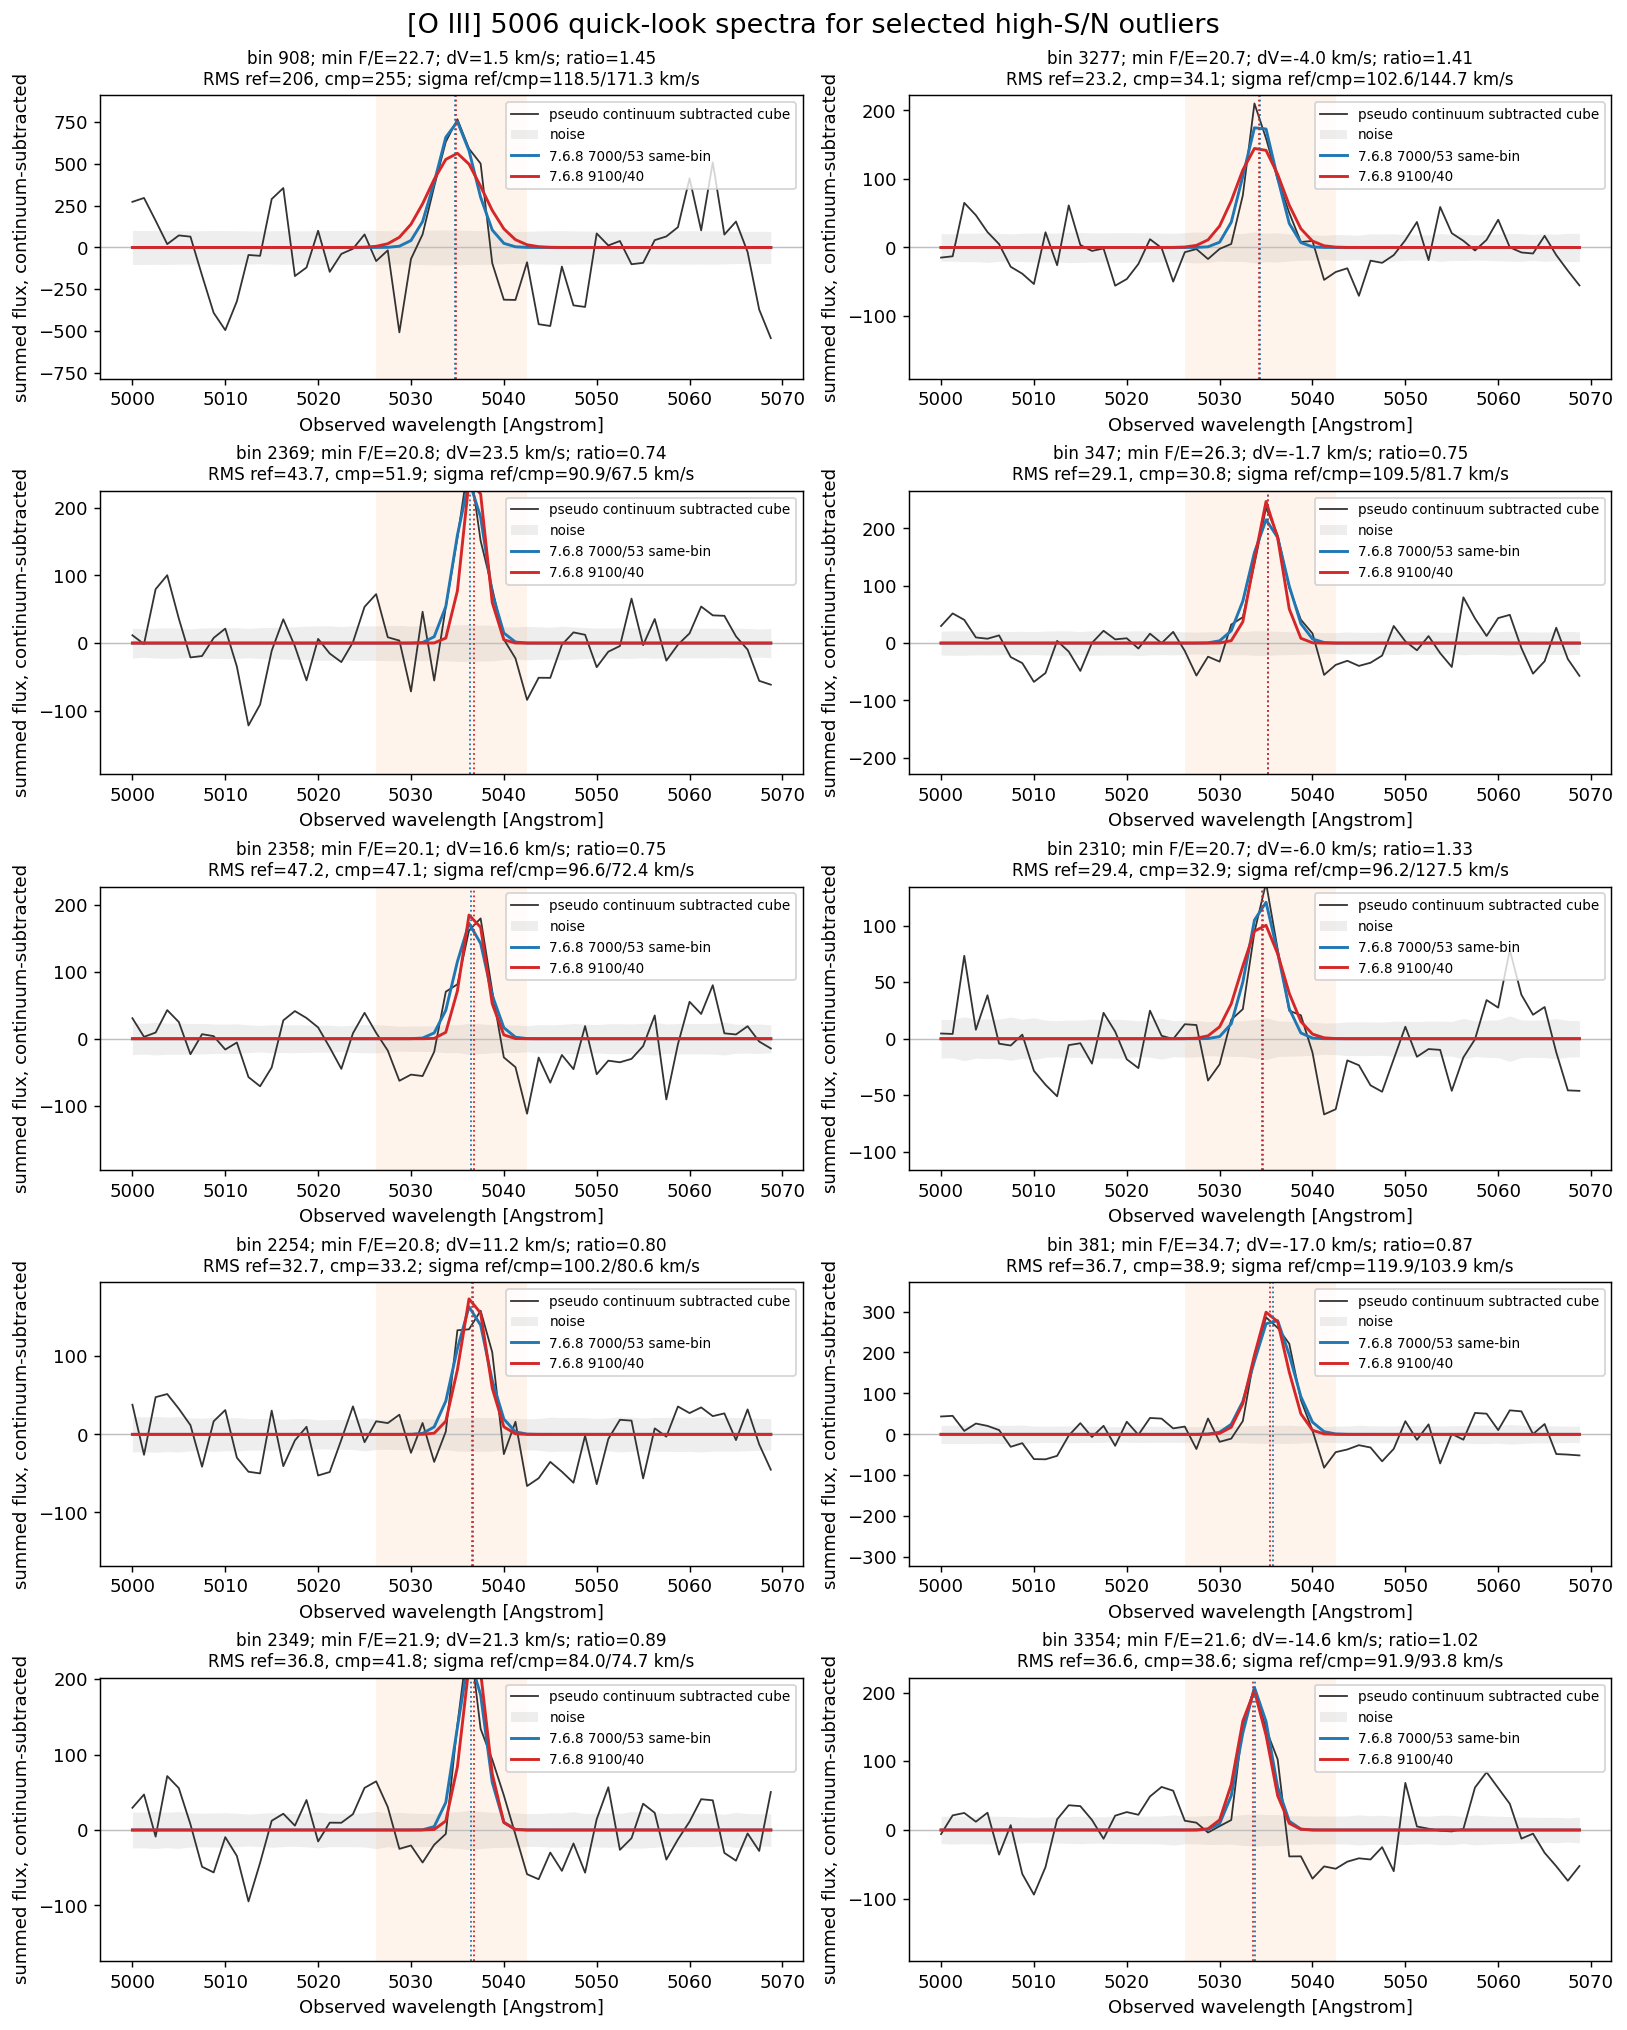

In [8]:
def plot_selected_spectra(spectra):
    if not spectra:
        print('No spectra to plot.')
        return
    n = len(spectra)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12.4, 3.1 * nrows), squeeze=False, constrained_layout=True)
    fig.suptitle(f'{OIII_LABEL} quick-look spectra for selected high-S/N outliers', fontsize=15)

    for ax, spec in zip(axes.ravel(), spectra):
        row = spec['row']
        wave = spec['wave']
        contsub = spec['contsub']
        ref_fit = spec['ref_fit']
        cmp_fit = spec['cmp_fit']
        line_window = spec['line_window']
        finite_contsub = contsub[np.isfinite(contsub)]
        y_scale = np.nanpercentile(np.abs(finite_contsub), 98) if finite_contsub.size else 1.0
        y_scale = y_scale if np.isfinite(y_scale) and y_scale > 0 else 1.0

        ax.axhline(0, color='0.75', linewidth=0.8)
        ax.plot(wave, contsub, color='0.2', linewidth=1.0, label='pseudo continuum subtracted cube')
        if np.isfinite(spec['noise']).any():
            ax.fill_between(wave, -spec['noise'], spec['noise'], color='0.7', alpha=0.22, linewidth=0, label='noise')
        ax.plot(wave, ref_fit['model'], color=RUNS[BASELINE_RUN]['color'], linewidth=1.6, label=RUNS[BASELINE_RUN]['plot_label'])
        ax.plot(wave, cmp_fit['model'], color=RUNS[COMPARE_RUN]['color'], linewidth=1.6, label=RUNS[COMPARE_RUN]['plot_label'])
        ax.axvspan(wave[line_window].min(), wave[line_window].max(), color='tab:orange', alpha=0.08, linewidth=0)
        ax.axvline(ref_fit['center'], color=RUNS[BASELINE_RUN]['color'], linestyle=':', linewidth=1)
        ax.axvline(cmp_fit['center'], color=RUNS[COMPARE_RUN]['color'], linestyle=':', linewidth=1)

        title = (
            f'bin {int(row["bin_id"])}; min F/E={row["both_fluxerr_min"]:.1f}; '
            f'dV={row["delta_vel"]:.1f} km/s; ratio={row["sigma_ratio"]:.2f}'
        )
        subtitle = (
            f'RMS ref={ref_fit["rms"]:.3g}, cmp={cmp_fit["rms"]:.3g}; '
            f'sigma ref/cmp={row["ref_sigma"]:.1f}/{row["cmp_sigma"]:.1f} km/s'
        )
        ax.set_title(title + '\n' + subtitle, fontsize=9.3)
        ax.set_xlabel('Observed wavelength [Angstrom]')
        ax.set_ylabel('summed flux, continuum-subtracted')
        ax.set_ylim(-1.25 * y_scale, 1.45 * y_scale)
        ax.legend(loc='upper right', fontsize=7.5, frameon=True)

    for ax in axes.ravel()[len(spectra):]:
        ax.axis('off')
    plt.show()


plot_selected_spectra(selected_spectra)


## [S III] 9068 Check For The Same Selected OIII Bins

`SIII9068` is outside the `7000/53 same-bin` wavelength range, so this is not a two-run comparison. Instead, it is a companion sanity check for the `9100/40` iteration: for the same suspicious OIII-selected bins, inspect whether the red `[S III] 9068` line is consistent with the `9100/40` kinematics.

The next cell does three things:

1. Load `SIII9068_FLUX`, `SIII9068_FLUX_ERR`, `SIII9068_VEL`, and `SIII9068_SIGMA` from the `9100/40` GAS map.
2. Collapse those maps to the same selected `BIN_ID` list used above, so each selected OIII outlier gets an `[S III]` row with `[S III] Flux/Err`, velocity, sigma, and differences relative to the `9100/40` OIII map values.
3. Extract the observed cube spectrum around `[S III] 9068` for each selected bin, subtract a local linear continuum, and overlay a single Gaussian model using the `9100/40` `[S III]` map-level `VEL` and `SIGMA`.

As above, the gray band is `1 sigma` noise from the cube `STAT` variance summed over the bin spaxels, and the orange shaded region is the central line window used for the quick amplitude fit and RMS number. This is a visual check of whether the `9100/40` tied-kinematics solution looks plausible in `[S III]`, not a reproduction of the full pPXF fit.


SIII9068 available in 7.6.8 9100/40: True


,selection_reason,bin_id,row,col,n_spaxels,oiii_min_fluxerr,siii_flux,siii_flux_err,siii_fluxerr,oiii_cmp_vel,siii_vel,siii_minus_oiii_vel,oiii_cmp_sigma,siii_sigma,siii_minus_oiii_sigma,siii_vel_err,siii_sigma_err,siii_sigma_corr
0,large sigma ratio,908,87.0,187.0,451,22.660587,6.929226,0.653827,10.597955,6.451486,6.451486,0.0,171.261349,162.785805,-8.475544,8.621629,8.112020,35.234107
1,large sigma ratio,3277,200.0,292.0,8,20.713541,101.022445,8.321406,12.140069,-25.456181,-25.456181,0.0,144.692923,134.554118,-10.138805,7.951118,8.735759,35.234107
2,large sigma ratio,2369,304.0,162.0,16,20.822391,80.119441,3.077374,26.035000,123.706687,123.706687,0.0,67.464929,41.476323,-25.988606,1.993316,4.205389,35.234107
3,large sigma ratio,347,195.0,213.0,11,26.311498,173.965448,4.905627,35.462431,27.753184,27.753184,0.0,81.719768,62.023295,-19.696472,2.070545,2.733211,35.234107
4,large sigma ratio,2358,297.5,192.0,10,20.131734,68.192060,4.091462,16.666916,121.533030,121.533030,0.0,72.442063,49.159142,-23.282921,3.154628,5.221892,35.234107
5,large sigma ratio,2310,229.5,256.5,4,20.687368,127.893715,11.554758,11.068489,-8.576171,-8.576171,0.0,127.527705,115.896870,-11.630836,7.201039,8.118003,35.234107
6,large velocity difference,2254,296.0,190.0,9,20.772796,85.009549,4.697763,18.095752,119.145108,119.145108,0.0,80.576453,60.508955,-20.067499,3.516154,4.889558,35.234107
7,large velocity difference,381,193.0,211.0,11,34.735023,164.759072,5.747728,28.665078,42.757784,42.757784,0.0,103.858872,89.193240,-14.665632,2.931429,3.544400,35.234107
8,large velocity difference,2349,298.5,188.0,10,21.881667,96.061208,4.770841,20.135067,125.969164,125.969164,0.0,74.678956,52.399573,-22.279383,2.853875,4.368143,35.234107
9,large velocity difference,3354,164.0,284.0,9,21.572330,32.706561,5.609103,5.830979,-65.480938,-65.480938,0.0,93.781015,77.224656,-16.556359,5.217600,7.709770,35.234107


Extracted SIII spectra for 10 selected bins.


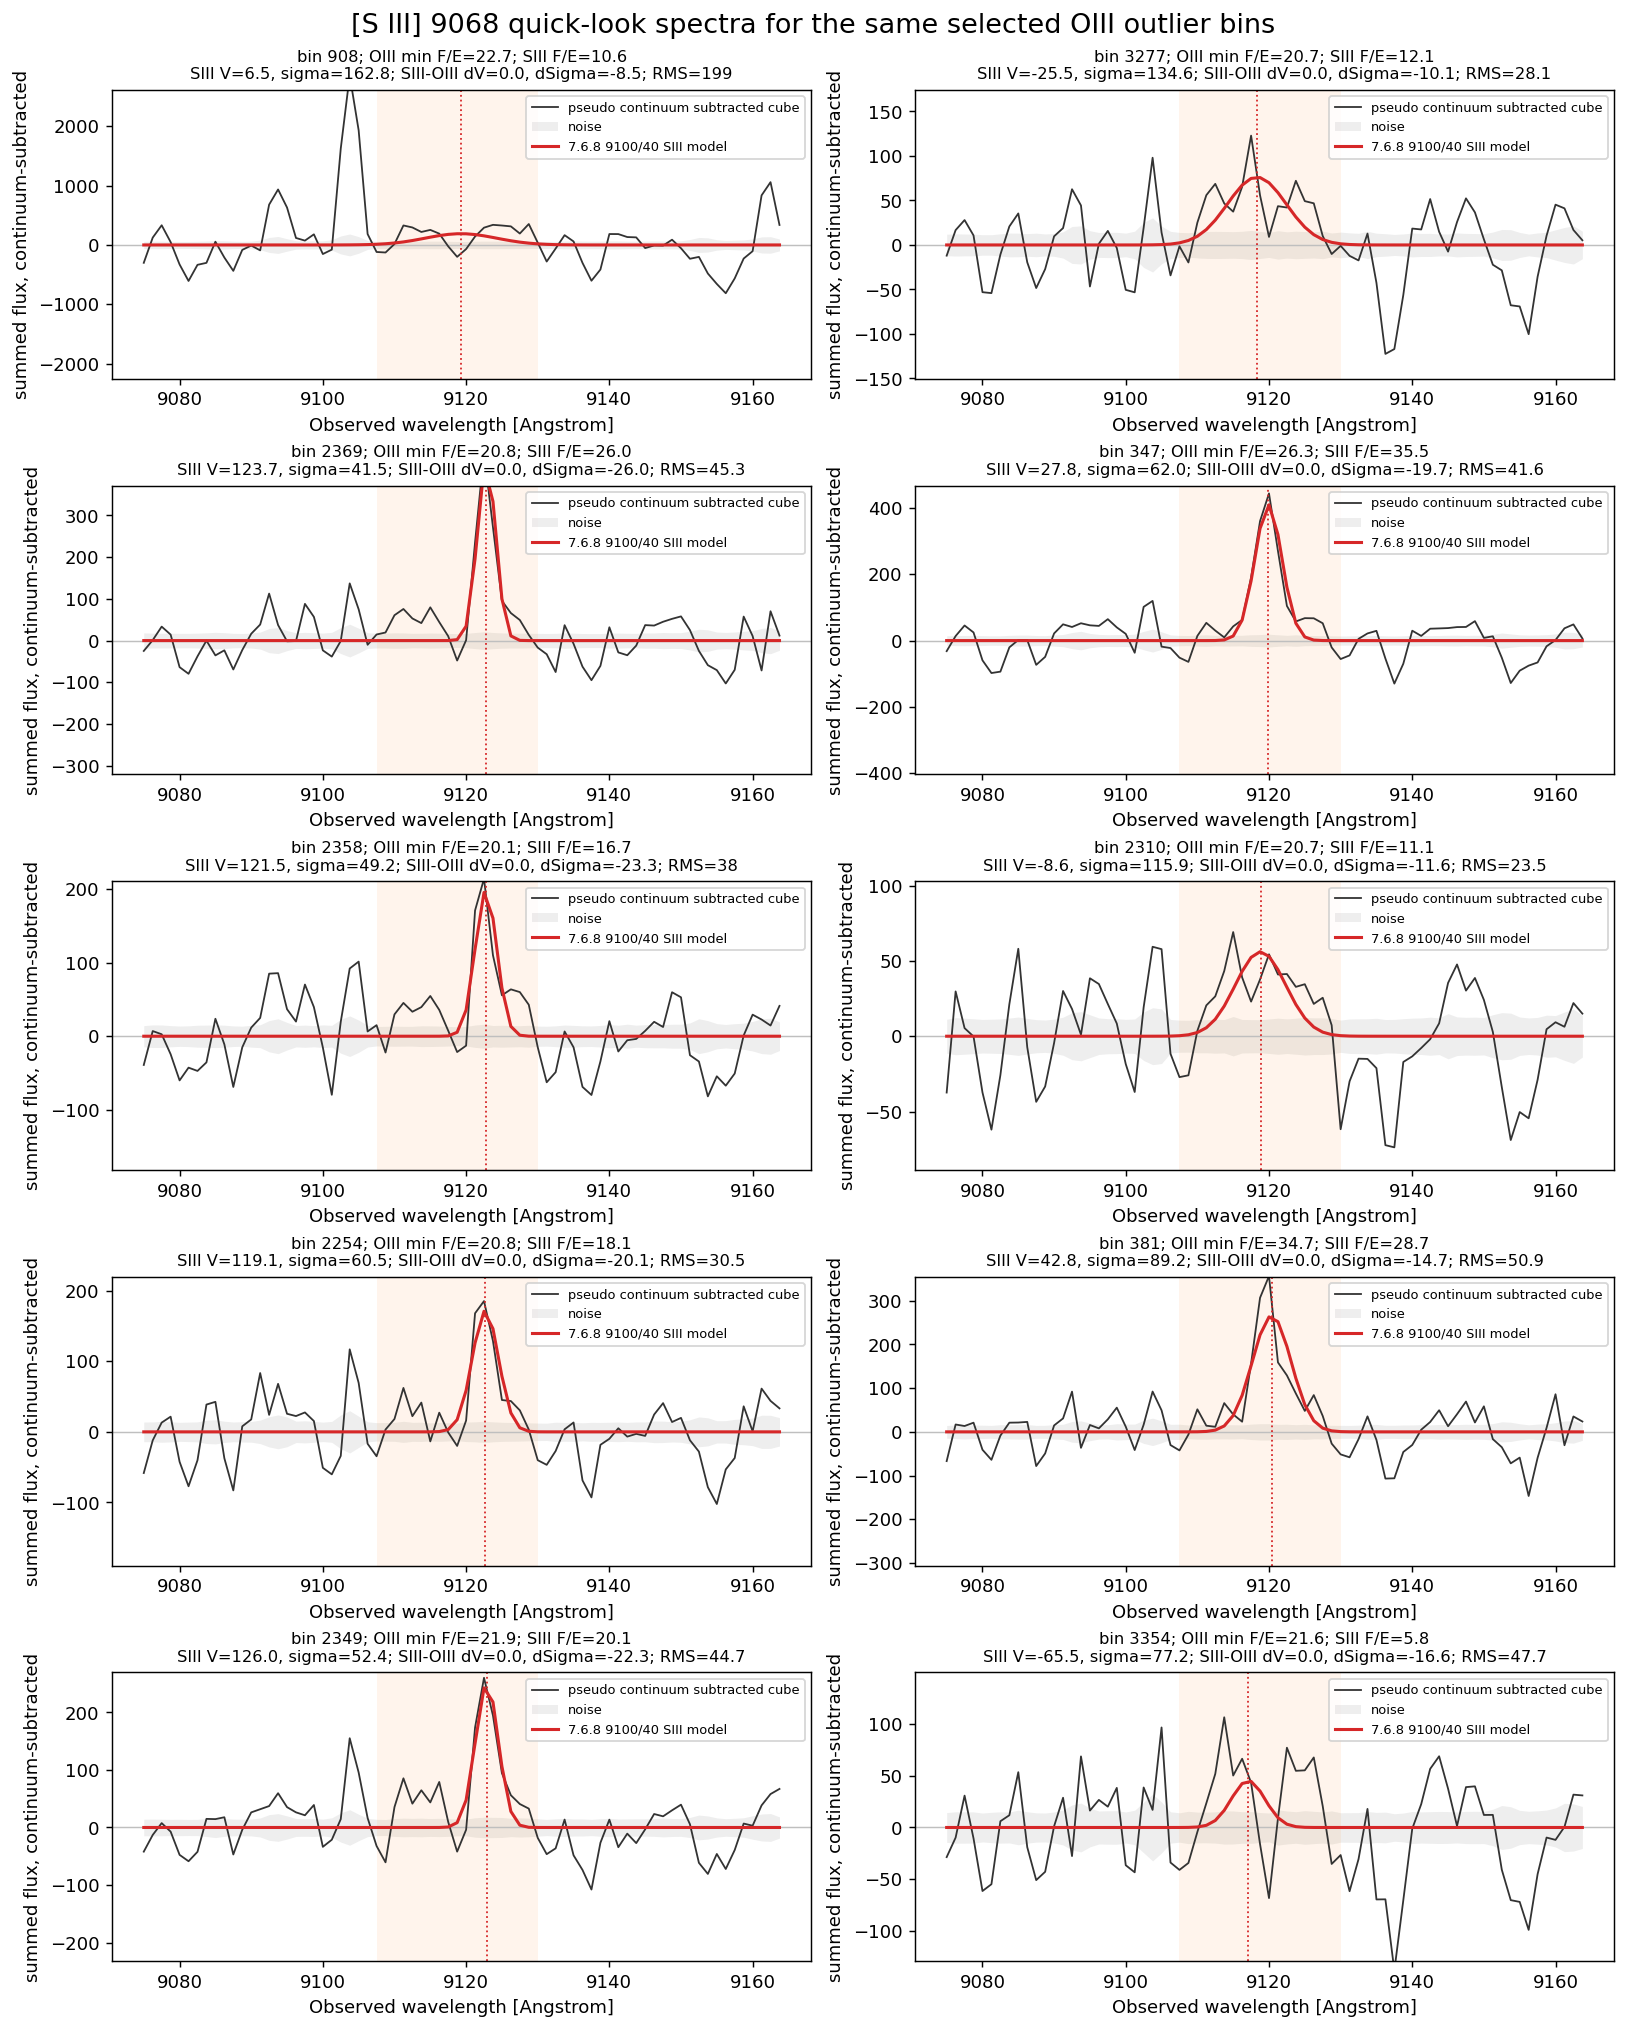

In [9]:
SIII_LINE = 'SIII9068'
SIII_LABEL = '[S III] 9068'
SIII_REST_A = 9068.6
SIII_RUN = COMPARE_RUN
SIII_REQUIRED_EXTENSIONS = [
    f'{SIII_LINE}_FLUX',
    f'{SIII_LINE}_FLUX_ERR',
    f'{SIII_LINE}_VEL',
    f'{SIII_LINE}_VEL_ERR',
    f'{SIII_LINE}_SIGMA',
    f'{SIII_LINE}_SIGMA_ERR',
    f'{SIII_LINE}_SIGMA_CORR',
]

siii_available = set(fits_extnames(RUNS[SIII_RUN]['gas_path']))
missing_siii = [ext for ext in SIII_REQUIRED_EXTENSIONS if ext not in siii_available]
print(f'{SIII_LINE} available in {RUNS[SIII_RUN]["plot_label"]}:', not missing_siii)
if missing_siii:
    print('Missing SIII extensions:', missing_siii)

siii_maps = {ext: read_map(RUNS[SIII_RUN]['gas_path'], ext) for ext in SIII_REQUIRED_EXTENSIONS if ext in siii_available}


def median_map_value_for_bin(arr, bin_id):
    values = arr[baseline_bins == int(bin_id)]
    values = values[np.isfinite(values)]
    return float(np.nanmedian(values)) if values.size else np.nan


def siii_selected_row(row):
    bin_id = int(row['bin_id'])
    flux = median_map_value_for_bin(siii_maps[f'{SIII_LINE}_FLUX'], bin_id)
    flux_err = median_map_value_for_bin(siii_maps[f'{SIII_LINE}_FLUX_ERR'], bin_id)
    fluxerr = flux / flux_err if np.isfinite(flux) and np.isfinite(flux_err) and flux_err > 0 else np.nan
    vel = median_map_value_for_bin(siii_maps[f'{SIII_LINE}_VEL'], bin_id)
    sigma = median_map_value_for_bin(siii_maps[f'{SIII_LINE}_SIGMA'], bin_id)
    vel_err = median_map_value_for_bin(siii_maps[f'{SIII_LINE}_VEL_ERR'], bin_id)
    sigma_err = median_map_value_for_bin(siii_maps[f'{SIII_LINE}_SIGMA_ERR'], bin_id)
    sigma_corr = median_map_value_for_bin(siii_maps[f'{SIII_LINE}_SIGMA_CORR'], bin_id)
    return {
        'selection_reason': row['selection_reason'],
        'bin_id': bin_id,
        'row': row['row'],
        'col': row['col'],
        'n_spaxels': row['n_spaxels'],
        'oiii_min_fluxerr': row['both_fluxerr_min'],
        'siii_flux': flux,
        'siii_flux_err': flux_err,
        'siii_fluxerr': fluxerr,
        'oiii_cmp_vel': row['cmp_vel'],
        'siii_vel': vel,
        'siii_minus_oiii_vel': vel - row['cmp_vel'],
        'oiii_cmp_sigma': row['cmp_sigma'],
        'siii_sigma': sigma,
        'siii_minus_oiii_sigma': sigma - row['cmp_sigma'],
        'siii_vel_err': vel_err,
        'siii_sigma_err': sigma_err,
        'siii_sigma_corr': sigma_corr,
    }


if missing_siii:
    siii_selected_summary = pd.DataFrame()
    siii_spectra = []
else:
    siii_selected_summary = pd.DataFrame([siii_selected_row(row) for _, row in selected_bins.iterrows()])
    display(siii_selected_summary)


def fitted_siii_gaussian(wave, spectrum_contsub, row, line_window_mask):
    vel = row['siii_vel']
    sigma_kms = row['siii_sigma']
    center = SIII_REST_A * (1.0 + REDSHIFT) * (1.0 + vel / C_KMS)
    sigma_a = center * sigma_kms / C_KMS
    profile = gaussian_unit(wave, center, sigma_a)
    fit_mask = line_window_mask & np.isfinite(profile) & np.isfinite(spectrum_contsub)
    if fit_mask.sum() < 3:
        amp = np.nan
        model = np.full(wave.shape, np.nan)
        rms = np.nan
    else:
        denom = np.nansum(profile[fit_mask] ** 2)
        amp = np.nansum(spectrum_contsub[fit_mask] * profile[fit_mask]) / denom if denom > 0 else np.nan
        model = amp * profile
        rms = np.sqrt(np.nanmean((spectrum_contsub[fit_mask] - model[fit_mask]) ** 2))
    return {'center': center, 'sigma_a': sigma_a, 'amp': amp, 'model': model, 'rms': rms, 'vel': vel, 'sigma_kms': sigma_kms}


def extract_selected_siii_spectra(selected, wave_half_width=45.0, line_half_width=12.0, continuum_inner=20.0):
    if CUBE_PATH is None:
        print('No local cube found; skipping SIII spectral extraction.')
        return []
    if selected.empty:
        return []

    systemic_center = SIII_REST_A * (1.0 + REDSHIFT)
    with fits.open(CUBE_PATH, memmap=True) as hdul:
        cube = hdul['DATA'].data
        var = hdul['STAT'].data if 'STAT' in hdul else None
        wave = wavelength_from_header(hdul['DATA'].header, cube.shape[0])
        wave_mask = (wave >= systemic_center - wave_half_width) & (wave <= systemic_center + wave_half_width)
        wave_cut = wave[wave_mask]
        cube_cut = np.array(cube[wave_mask, :, :], dtype=float)
        var_cut = np.array(var[wave_mask, :, :], dtype=float) if var is not None else None

    line_window = np.abs(wave_cut - systemic_center) <= line_half_width
    continuum_window = (np.abs(wave_cut - systemic_center) >= continuum_inner) & np.isfinite(wave_cut)
    spectra = []

    for _, row in selected.iterrows():
        bin_id = int(row['bin_id'])
        bin_mask = baseline_bins == bin_id
        if not np.any(bin_mask):
            continue
        spectrum = np.nansum(cube_cut[:, bin_mask], axis=1)
        if var_cut is not None:
            variance = np.nansum(var_cut[:, bin_mask], axis=1)
            noise = np.sqrt(np.clip(variance, 0, np.inf))
        else:
            noise = np.full_like(spectrum, np.nan)

        continuum_fit_mask = continuum_window & np.isfinite(spectrum)
        if continuum_fit_mask.sum() >= 4:
            coeff = np.polyfit(wave_cut[continuum_fit_mask], spectrum[continuum_fit_mask], deg=1)
            continuum = np.polyval(coeff, wave_cut)
        else:
            continuum = np.full_like(spectrum, np.nanmedian(spectrum))
        contsub = spectrum - continuum
        fit = fitted_siii_gaussian(wave_cut, contsub, row, line_window)
        spectra.append({
            'bin_id': bin_id,
            'row': row,
            'wave': wave_cut,
            'spectrum': spectrum,
            'noise': noise,
            'continuum': continuum,
            'contsub': contsub,
            'line_window': line_window,
            'fit': fit,
        })
    return spectra


siii_spectra = extract_selected_siii_spectra(siii_selected_summary)
print(f'Extracted SIII spectra for {len(siii_spectra)} selected bins.')


def plot_selected_siii_spectra(spectra):
    if not spectra:
        print('No SIII spectra to plot.')
        return
    n = len(spectra)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12.4, 3.1 * nrows), squeeze=False, constrained_layout=True)
    fig.suptitle(f'{SIII_LABEL} quick-look spectra for the same selected OIII outlier bins', fontsize=15)

    for ax, spec in zip(axes.ravel(), spectra):
        row = spec['row']
        wave = spec['wave']
        contsub = spec['contsub']
        fit = spec['fit']
        line_window = spec['line_window']
        finite_contsub = contsub[np.isfinite(contsub)]
        y_scale = np.nanpercentile(np.abs(finite_contsub), 98) if finite_contsub.size else 1.0
        y_scale = y_scale if np.isfinite(y_scale) and y_scale > 0 else 1.0

        ax.axhline(0, color='0.75', linewidth=0.8)
        ax.plot(wave, contsub, color='0.2', linewidth=1.0, label='pseudo continuum subtracted cube')
        if np.isfinite(spec['noise']).any():
            ax.fill_between(wave, -spec['noise'], spec['noise'], color='0.7', alpha=0.22, linewidth=0, label='noise')
        ax.plot(wave, fit['model'], color=RUNS[SIII_RUN]['color'], linewidth=1.7, label=f'{RUNS[SIII_RUN]["plot_label"]} SIII model')
        ax.axvspan(wave[line_window].min(), wave[line_window].max(), color='tab:orange', alpha=0.08, linewidth=0)
        ax.axvline(fit['center'], color=RUNS[SIII_RUN]['color'], linestyle=':', linewidth=1)

        title = (
            f'bin {int(row["bin_id"])}; OIII min F/E={row["oiii_min_fluxerr"]:.1f}; '
            f'SIII F/E={row["siii_fluxerr"]:.1f}'
        )
        subtitle = (
            f'SIII V={row["siii_vel"]:.1f}, sigma={row["siii_sigma"]:.1f}; '
            f'SIII-OIII dV={row["siii_minus_oiii_vel"]:.1f}, dSigma={row["siii_minus_oiii_sigma"]:.1f}; RMS={fit["rms"]:.3g}'
        )
        ax.set_title(title + '\n' + subtitle, fontsize=9.0)
        ax.set_xlabel('Observed wavelength [Angstrom]')
        ax.set_ylabel('summed flux, continuum-subtracted')
        ax.set_ylim(-1.25 * y_scale, 1.45 * y_scale)
        ax.legend(loc='upper right', fontsize=7.2, frameon=True)

    for ax in axes.ravel()[len(spectra):]:
        ax.axis('off')
    plt.show()


plot_selected_siii_spectra(siii_spectra)


## Optional Save

Uncomment these lines if you want CSV tables for follow-up notes or manual inspection.


In [10]:
# population_summary.to_csv('IC3392_OIII_fluxerr_population_20260511.csv', index=False)
# selected_bins[selected_cols].to_csv('IC3392_OIII_highSN_selected_outlier_bins_20260511.csv', index=False)
# bin_table.to_csv('IC3392_OIII_one_row_per_bin_20260511.csv', index=False)
